# US equities panel: the same names, sized differently

[`16_backtest`](16_backtest.ipynb) put the same amount of money in every position. That is the
plainest rule there is, and it embeds an assumption worth naming: that a stock the model ranked
first and a stock it ranked fiftieth deserve the same capital, and that a quiet stock and a
violent one do too.

This notebook keeps the names and changes only the money. The model, the checkpoint, the
rebalancing dates and which stocks are held are all held fixed; what varies is how much goes into
each. Every allocator declared in `config/setup.yaml` is applied, and they answer the question
in three different ways:

- **From the prediction.** `score_weighted` gives more capital to the names the model was more
  confident about, so it trusts the magnitude of a prediction and not only its order.
  `conformal_weighted` reads the prediction's uncertainty rather than its size: it weights each
  name by one over the width of its prediction interval, so a name the model is less sure about
  gets less capital. The width is floored at the first percentile of that date's own
  cross-section before the reciprocal is taken, which keeps an unusually confident name from
  taking the whole leg and uses no width from a later date to do it. That is the same width whose
  calibration [`15_model_analysis`](15_model_analysis.ipynb) checked, which is why the check
  there matters here.
- **From each stock's own volatility.** `inverse_vol` puts less into a stock that moves more, so
  each position contributes a similar amount of variation rather than a similar amount of money.
  `risk_parity` as implemented here is the same idea with a steeper exponent on volatility,
  which approximates equal risk contribution without estimating how the stocks move together.
- **From how the stocks move together.** `mvo_ledoit_wolf` and `hrp` read a covariance matrix, so
  they alone can tell that two names which always move together are one bet held twice. That is
  the property none of the rules above can see, and it is the one that has to be estimated. These
  two need history before they can decide anything, and how much is declared per allocator rather
  than assumed.

**Equal weight is excluded here because its backtest already exists.** It is the baseline every
row is measured against, and [`16_backtest`](16_backtest.ipynb) ran it.

**A shortlist is taken first, and that is a real decision.** Applying every allocator to every
member of the whole model population would multiply an already large grid by seven. So the
highest validation Sharpe per distinct model configuration is carried forward, which means the
allocator comparison is made on strategies the equal-weight rule already liked. An allocator that
rescues a model equal weight buried is not something this design can find.

**Learning objectives.** By the end of this notebook you will be able to:

- Name the assumption an equal-weight book makes about its positions, and say what each family
  of allocator replaces it with.
- Say what a covariance-reading allocator can see that a per-stock one cannot, what it needs in
  exchange, and which of the declared allocators actually read one.
- Explain why a lookback window is declared per allocator rather than shared, and what a shared
  one would silently do to the ones that need less.
- State what a shortlist taken on baseline Sharpe makes it impossible for this comparison to
  discover.

**Book reference**: Chapter 17, Sections 17.2 to 17.8.

**Prerequisites**: [`16_backtest`](16_backtest.ipynb) has frozen the equal-weight baseline sets
this notebook draws from.

**What it writes**: one validation backtest per surviving configuration and allocator, in
`run_log/registry.db`, frozen as one named allocation set per label.
[`18_risk_management`](18_risk_management.ipynb) reads them next.

In [1]:
"""Generate the US-equities allocation-stage validation population."""

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from case_studies.research import (
    CandidateSet,
    OfficialPopulation,
    candidate_set_supersedes,
    open_study,
    plan_backtests,
    population_supersedes,
    run_backtests,
)
from case_studies.research.strategy import strategy_warmup_periods
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
)
from case_studies.utils.notebook_contracts import degenerate_prediction_hashes
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_n_predictions,
)
from utils.style import add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
BASELINE_SET_NAMES = [
    "us-equities-fwd-ret-1d-baseline-v1",
]
EXECUTION_TIER = "canonical"
POPULATION_NAME = ""
SUPERSEDES_POPULATION = ""
SUPERSEDES_SETS: dict = {}
# Empty means this run writes to the case study's own store, which is what canonical
# production execution wants. Any other value routes the run's writes there instead, at
# either tier, and is how a rehearsal at full scale is compared against the published
# result without being able to damage it.
WORKSPACE = ""
PREVIEW_LABELS = []
PREVIEW_MAX_BASELINE_ROWS = 0
PREVIEW_MAX_ALLOCATORS = 0
MAX_SYMBOLS = 0
# None means the width `setup.yaml` declares; an int overrides it. Declared here because
# papermill only binds a name the parameters cell already holds - a run that passes
# TOP_N_PREDICTIONS to a notebook without it sweeps the declared width and exits 0.
TOP_N_PREDICTIONS = None

## 2. The baseline this notebook varies

The equal-weight sets are opened and checked complete. Everything below changes one thing about
them, so a gap here would silently narrow what the allocator comparison is made over.

Both tiers resolve the study through `open_study`. It reads the labels and features in place and
redirects only writes, so a preview run scores the same inputs a canonical one does and cannot
publish over it.

In [4]:
workspace_override = os.environ.get("ML4T_OUTPUT_DIR") or WORKSPACE
if EXECUTION_TIER == "canonical":
    if PREVIEW_LABELS or PREVIEW_MAX_BASELINE_ROWS or PREVIEW_MAX_ALLOCATORS or MAX_SYMBOLS:
        raise ValueError("Canonical execution cannot declare preview reductions")
    if not BASELINE_SET_NAMES or len(BASELINE_SET_NAMES) != len(set(BASELINE_SET_NAMES)):
        raise ValueError("Canonical execution requires unique named baseline sets")
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(workspace_override) if workspace_override else None,
    )
elif EXECUTION_TIER == "preview":
    if (
        not PREVIEW_LABELS
        or PREVIEW_MAX_BASELINE_ROWS < 1
        or PREVIEW_MAX_ALLOCATORS < 1
        or MAX_SYMBOLS < 1
    ):
        raise ValueError(
            "Preview execution requires labels and explicit row, allocator, and symbol limits"
        )
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(workspace_override or "experiments"),
    )
else:
    raise ValueError(f"Unsupported execution tier: {EXECUTION_TIER!r}")

## 3. Which baseline rows can be re-sized

Complete, validation-split, and produced under this run's tier. A row failing any of those is
refused rather than dropped, so the shortlist below is taken from a population that means what it
says.

In [5]:
backtest_catalog = study.backtests.table(include_preview=True)
if EXECUTION_TIER == "canonical":
    baseline_sets = tuple(CandidateSet.one(study, name=name) for name in BASELINE_SET_NAMES)
    if any(result_set.member_kind != "backtest" for result_set in baseline_sets):
        raise ValueError("Every declared baseline set must contain backtests")
    baseline_members = tuple(
        member for result_set in baseline_sets for member in result_set.members
    )
    if len(baseline_members) != len(set(baseline_members)):
        raise ValueError("Declared baseline sets overlap")
    baseline = backtest_catalog.filter(pl.col("backtest_hash").is_in(baseline_members))
    if baseline.height != len(baseline_members):
        raise ValueError("The backtest catalog does not contain every baseline member")
else:
    baseline = (
        backtest_catalog.filter(
            (pl.col("execution_tier") == "preview")
            & (pl.col("stage") == "signal")
            & pl.col("label").is_in(PREVIEW_LABELS)
        )
        .sort("sharpe", "backtest_hash", descending=[True, False])
        .head(PREVIEW_MAX_BASELINE_ROWS)
    )

ineligible = baseline.filter(
    (pl.col("split") != "validation")
    | (pl.col("execution_tier") != EXECUTION_TIER)
    | (pl.col("stage") != "signal")
    | ~pl.col("complete")
    | pl.col("sharpe").is_null()
    | ~pl.col("sharpe").is_finite()
)
if baseline.is_empty() or not ineligible.is_empty():
    raise ValueError("Allocation requires complete finite equal-weight validation rows")

## 3b. The rows that rank but do not forecast

A regularized linear model that shrinks every coefficient to zero on a fold predicts one
constant for that fold. The backtest still runs: a constant score ranks nothing, so the
top-k rule holds whichever names the tie-break leaves on top and the book turns into a slow
buy-and-hold. That book has a *good*-looking Sharpe here, because it trades 5,761 times
instead of 121,521 and so pays almost none of the costs that dominate every real member.

**This is an exclusion, not a refusal.** The rows above are legitimate members of the
baseline population and the sweep that produced them has no degeneracy filter of its own -
the same gap `nasdaq100_microstructure/14_backtest` closes at the point of use. What must not
happen is that they reach a leaderboard: `selectable_validation_candidates` already refuses
them when it resolves the carrier, so without this the allocator comparison and the carrier
pool would disagree about which configurations exist.

In [6]:
degenerate = degenerate_prediction_hashes(study.root)
excluded = baseline.filter(pl.col("prediction_hash").is_in(degenerate))
baseline = baseline.filter(~pl.col("prediction_hash").is_in(degenerate))
if baseline.is_empty():
    raise ValueError("Every baseline row is a constant-prediction set")
print(
    f"{excluded.height} of {excluded.height + baseline.height} baseline rows excluded as "
    f"constant-prediction sets, leaving {baseline.height}"
)
excluded.select("label", "family", "config_name", "prediction_hash", "sharpe", "max_drawdown")

8 of 464 baseline rows excluded as constant-prediction sets, leaving 456


label,family,config_name,prediction_hash,sharpe,max_drawdown
str,str,str,str,f64,f64
"""fwd_ret_1d""","""linear""","""lasso_a0.1""","""224d5163f76a""",0.606173,-0.208187
"""fwd_ret_1d""","""linear""","""lasso_a0.01""","""5780d8d47c62""",0.606173,-0.208187
"""fwd_ret_1d""","""linear""","""enet_a0.1""","""7724bca14192""",0.137654,-0.351949
"""fwd_ret_1d""","""linear""","""lasso_a0.1""","""224d5163f76a""",0.137654,-0.351949
"""fwd_ret_1d""","""linear""","""enet_a0.1""","""7724bca14192""",0.606173,-0.208187
"""fwd_ret_1d""","""linear""","""enet_a0.01""","""ebe532adebaf""",0.137654,-0.351949
"""fwd_ret_1d""","""linear""","""enet_a0.01""","""ebe532adebaf""",0.606173,-0.208187
"""fwd_ret_1d""","""linear""","""lasso_a0.01""","""5780d8d47c62""",0.137654,-0.351949


## 4. The shortlist, and what it costs

One row per distinct model configuration, taken on baseline Sharpe. Without it every allocator
would be applied to every member of the whole model population, multiplying an already large grid
by the number of allocators.

**What that makes invisible is worth stating plainly.** The allocators are compared only on
strategies the equal-weight rule already ranked highly. An allocator whose value is precisely
that it rescues a model equal weight buried cannot be discovered by this design, and no result
below is evidence against one existing.

In [7]:
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
top_n = TOP_N_PREDICTIONS
checkpoints_per_config = get_checkpoints_per_config(CASE_STUDY_ID)
if checkpoints_per_config != 1:
    raise ValueError(
        "backtest.sweep.checkpoints_per_config is "
        f"{checkpoints_per_config}; this notebook advances one checkpoint per "
        "model configuration"
    )
shortlist_parts = []
for label in baseline.get_column("label").unique().sort().to_list():
    ranked = baseline.filter(pl.col("label") == label).sort(
        "sharpe", "backtest_hash", descending=[True, False]
    )
    shortlist_parts.append(
        ranked.unique(
            subset=["family", "config_name"],
            keep="first",
            maintain_order=True,
        ).head(top_n)
    )
shortlist = pl.concat(shortlist_parts).sort("label", "sharpe", descending=[False, True])
if shortlist.is_empty():
    raise RuntimeError("The equal-weight baseline produced no allocation survivors")

shortlist.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "prediction_hash",
    "backtest_hash",
    "sharpe",
)

label,family,config_name,checkpoint_kind,checkpoint_value,prediction_hash,backtest_hash,sharpe
str,str,str,str,i64,str,str,f64
"""fwd_ret_1d""","""gbm""","""leaves_63_mse""","""iteration""",500,"""a1c1ea483209""","""3076efd14f7c""",1.052785
"""fwd_ret_1d""","""gbm""","""default_mse""","""iteration""",500,"""b978d17c46af""","""cf86ebfb39c4""",0.510158
"""fwd_ret_1d""","""gbm""","""leaves_63_huber""","""iteration""",500,"""032f82080765""","""0238545ee136""",0.408973
"""fwd_ret_1d""","""gbm""","""leaves_31_mse""","""iteration""",500,"""85453e81d3ec""","""0e5523faf9c6""",0.392053
"""fwd_ret_1d""","""latent_factors""","""pca""","""epoch""",0,"""ab2c7bb27aa9""","""bc9084b35d1d""",0.256198
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""069241a40122""","""1e36a5a17dd1""",0.188143
"""fwd_ret_1d""","""gbm""","""leaves_7_mae""","""iteration""",500,"""0524fbd4df26""","""18fbc6bdba63""",0.177762
"""fwd_ret_1d""","""gbm""","""leaves_31_mae""","""iteration""",500,"""e8e3b30dda82""","""16a40222417b""",0.113174
"""fwd_ret_1d""","""gbm""","""leaves_63_mae""","""iteration""",450,"""dbeca39610e4""","""5349138e7f3d""",0.111132


## 5. Planning one backtest per allocator

Each surviving configuration crossed with each declared allocator, every identity written down
before the first runs.

**The history each allocator needs is declared per allocator, not shared.** The methods that read
a covariance matrix cannot decide anything until they have enough bars to estimate one, and the
amount differs between them - the mean-variance method here declares a longer window than the
others because shrinkage on a matrix estimated from too few observations pulls it all the way to
its target and hands back something close to equal weight under a different name. Each allocator
therefore declares the history it needs, and is measured on that.

`SUPERSEDES_POPULATION` and `SUPERSEDES_SETS` name the generation this run replaces. A population
and a candidate set are both immutable, so a re-run that admits different members has to say
which snapshot it supersedes or the registry refuses the write. Both default to empty, which is
right for a first run and for a reader's clean clone; `population_supersedes` and
`candidate_set_supersedes` withhold a declared hash wherever offering it would be refused.

**Prices are cached by label and warmup, not once per label.** Each allocator needs a different
amount of history before it can decide anything - none for the ones that read only the
predictions, a volatility window for the per-stock ones, a longer lookback for the ones that
estimate a covariance matrix - and the price frame a member was handed is digested into that
member's identity. So the frame has to be the one that member's own warmup implies, and the
cache key is what keeps it that way while still loading each distinct frame once.

In [8]:
_price_cache: dict[tuple[str, int], object] = {}


def prices_for(label, warmup_periods):
    key = (str(label), int(warmup_periods))
    if key not in _price_cache:
        _price_cache[key] = load_backtest_prices_for(
            CASE_STUDY_ID,
            label,
            split="validation",
            max_symbols=MAX_SYMBOLS,
            warmup_periods=int(warmup_periods),
        )
    return _price_cache[key]


allocators = [
    config for config in get_allocators(CASE_STUDY_ID) if config["method"] != "equal_weight"
]
if EXECUTION_TIER == "preview":
    allocators = allocators[:PREVIEW_MAX_ALLOCATORS]
if not allocators or any(config["method"] == "equal_weight" for config in allocators):
    raise ValueError("Allocation requires at least one non-baseline sizing method")

prediction_catalog = study.predictions.table(include_preview=True)
backtest_config = get_backtest_config(CASE_STUDY_ID)
planned_requests = []
plan_rows = []

In [9]:
def plan_allocation_member(label, prices, allocation, baseline_row):
    selected_prediction = prediction_catalog.filter(
        pl.col("prediction_hash") == baseline_row["prediction_hash"]
    )
    if selected_prediction.height != 1:
        raise ValueError("A baseline survivor must resolve one prediction catalog row")
    baseline_spec = json.loads(baseline_row["spec_json"])
    signal = dict(baseline_spec["strategy"]["signal"])
    plan = plan_backtests(
        study,
        predictions=selected_prediction,
        signal=signal,
        allocation=allocation,
        prices=prices,
        chapter="ch17",
    )
    if len(plan.members) != 1:
        raise RuntimeError("One allocation request must plan one backtest")
    expected_hash = plan.expected_hashes[0]
    request = {
        "label": label,
        "selection": selected_prediction,
        "signal": signal,
        "allocation": allocation,
        "prediction_hash": baseline_row["prediction_hash"],
        "expected_hash": expected_hash,
    }
    row = {
        "label": label,
        "family": baseline_row["family"],
        "config_name": baseline_row["config_name"],
        "checkpoint_kind": baseline_row["checkpoint_kind"],
        "checkpoint_value": baseline_row["checkpoint_value"],
        "allocation": allocation["method"],
        "prediction_hash": baseline_row["prediction_hash"],
        "backtest_hash": expected_hash,
    }
    return request, row

In [10]:
for label in shortlist.get_column("label").unique().sort().to_list():
    for baseline_row in shortlist.filter(pl.col("label") == label).iter_rows(named=True):
        for allocation in allocators:
            prices = prices_for(
                label, strategy_warmup_periods({"strategy": {"allocation": allocation}})
            )
            request, row = plan_allocation_member(label, prices, allocation, baseline_row)
            planned_requests.append(request)
            plan_rows.append(row)

In [11]:
planned_population = pl.DataFrame(plan_rows).sort(
    "label", "family", "config_name", "checkpoint_value", "allocation", "backtest_hash"
)
if planned_population.get_column("backtest_hash").n_unique() != planned_population.height:
    raise ValueError("The allocation plan contains duplicate backtest identities")

official_population = None
if EXECUTION_TIER == "canonical":
    population_name = POPULATION_NAME or "us-equities-allocation-v1"
    official_population = OfficialPopulation.create(
        study,
        name=population_name,
        supersedes=population_supersedes(
            study, name=population_name, declared=SUPERSEDES_POPULATION
        ),
        member_kind="backtest",
        members=tuple(planned_population.get_column("backtest_hash")),
    )

planned_population

label,family,config_name,checkpoint_kind,checkpoint_value,allocation,prediction_hash,backtest_hash
str,str,str,str,i64,str,str,str
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""conformal_weighted""","""069241a40122""","""b0b847543a58"""
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""hrp""","""069241a40122""","""0f10b17f1656"""
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""inverse_vol""","""069241a40122""","""14c3117e654e"""
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""mvo_ledoit_wolf""","""069241a40122""","""b88d77ff36ae"""
"""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",450,"""risk_parity""","""069241a40122""","""4030ec1a24cc"""
…,…,…,…,…,…,…,…
"""fwd_ret_1d""","""latent_factors""","""pca""","""epoch""",0,"""hrp""","""ab2c7bb27aa9""","""51b340b1e722"""
"""fwd_ret_1d""","""latent_factors""","""pca""","""epoch""",0,"""inverse_vol""","""ab2c7bb27aa9""","""e76a9830773c"""
"""fwd_ret_1d""","""latent_factors""","""pca""","""epoch""",0,"""mvo_ledoit_wolf""","""ab2c7bb27aa9""","""e336dae03d30"""


## 6. Running them

Independent per member, so a failure costs that allocator on that configuration and leaves the
rest usable.

In [12]:
execution_rows = []
failure_rows = []


def execute_allocation_member(prices, request):
    execution = run_backtests(
        study,
        predictions=request["selection"],
        signal=request["signal"],
        allocation=request["allocation"],
        prices=prices,
        chapter="ch17",
    )
    if len(execution.results) != 1 or execution.results[0].hash != request["expected_hash"]:
        raise RuntimeError("Allocation execution changed its planned identity")
    return {
        "label": request["label"],
        "prediction_hash": request["prediction_hash"],
        "allocation": request["allocation"]["method"],
        "backtest_hash": execution.results[0].hash,
        "status": execution.diagnostics[0]["status"],
    }

In [13]:
for label in shortlist.get_column("label").unique().sort().to_list():
    for request in (item for item in planned_requests if item["label"] == label):
        try:
            prices = prices_for(
                label,
                strategy_warmup_periods({"strategy": {"allocation": request["allocation"]}}),
            )
            execution_rows.append(execute_allocation_member(prices, request))
        except Exception as error:
            failure_rows.append(
                {
                    "label": label,
                    "prediction_hash": request["prediction_hash"],
                    "allocation": request["allocation"]["method"],
                    "backtest_hash": request["expected_hash"],
                    "error_type": type(error).__name__,
                    "error": str(error),
                }
            )

case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


In [14]:
execution_diagnostics = pl.DataFrame(
    execution_rows,
    schema={
        "label": pl.String,
        "prediction_hash": pl.String,
        "allocation": pl.String,
        "backtest_hash": pl.String,
        "status": pl.String,
    },
)
failures = pl.DataFrame(
    failure_rows,
    schema={
        "label": pl.String,
        "prediction_hash": pl.String,
        "allocation": pl.String,
        "backtest_hash": pl.String,
        "error_type": pl.String,
        "error": pl.String,
    },
)
if not failures.is_empty():
    raise RuntimeError(f"Allocation population has {failures.height} unsuccessful members")

if official_population is not None:
    official_population.require_complete()

execution_diagnostics

label,prediction_hash,allocation,backtest_hash,status
str,str,str,str,str
"""fwd_ret_1d""","""a1c1ea483209""","""score_weighted""","""9a8925197ac5""","""reused"""
"""fwd_ret_1d""","""a1c1ea483209""","""inverse_vol""","""699016aef9a8""","""reused"""
"""fwd_ret_1d""","""a1c1ea483209""","""risk_parity""","""0cbab3b9d9bd""","""reused"""
"""fwd_ret_1d""","""a1c1ea483209""","""mvo_ledoit_wolf""","""589306ef8e1a""","""reused"""
"""fwd_ret_1d""","""a1c1ea483209""","""hrp""","""3bc817cb3ae1""","""reused"""
…,…,…,…,…
"""fwd_ret_1d""","""20fe0c319f4a""","""inverse_vol""","""874dc57df944""","""completed"""
"""fwd_ret_1d""","""20fe0c319f4a""","""risk_parity""","""24bc0a1870e5""","""completed"""
"""fwd_ret_1d""","""20fe0c319f4a""","""mvo_ledoit_wolf""","""5e0ca027f966""","""completed"""


## 7. Naming the allocation sets

One frozen set per label, published only by an unnarrowed canonical run, for the reason
[`16_backtest`](16_backtest.ipynb) gives.

**The freeze is also the comparability check.** Nothing is declared comparable, so
`CandidateSet.create` requires every field of the protocol to be identical across the members:
two rows that measured their Sharpe on different folds are not two rankings of one thing, and
this is what refuses to freeze them together.

In [15]:
set_rows = []
completed = study.backtests.table(include_preview=True).filter(
    pl.col("backtest_hash").is_in(planned_population.get_column("backtest_hash"))
)
if (
    completed.height != planned_population.height
    or completed.filter(~pl.col("complete")).height
    or completed.filter(pl.col("stage") != "allocation").height
    or completed.filter(pl.col("execution_tier") != EXECUTION_TIER).height
    or completed.filter(pl.col("sharpe").is_null() | ~pl.col("sharpe").is_finite()).height
):
    raise RuntimeError("The allocation catalog is incomplete or mis-staged")
if EXECUTION_TIER == "canonical":
    for label in completed.get_column("label").unique().sort().to_list():
        label_name = label.replace("_", "-")
        result_set_name = f"us-equities-{label_name}-allocation-v1"
        result_set = study.backtests.freeze(
            completed.filter(pl.col("label") == label),
            name=result_set_name,
            supersedes=candidate_set_supersedes(
                study, name=result_set_name, declared=SUPERSEDES_SETS.get(result_set_name, "")
            ),
        )
        set_rows.append(
            {"label": label, "set_name": result_set.name, "members": len(result_set.members)}
        )

compatible_sets = pl.DataFrame(
    set_rows,
    schema={"label": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

/tmp/ipykernel_1436331/1644421264.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  completed = study.backtests.table(include_preview=True).filter(


label,set_name,members
str,str,i64
"""fwd_ret_1d""","""us-equities-fwd-ret-1d-allocat…",60


## 8. What came out

Each allocator against the equal-weight row it was built from. The comparison is like-for-like:
same model, same checkpoint, same names, same dates, different money.

**A small difference is a result.** Equal weight is a strong baseline on a broad cross-section
precisely because it makes no estimate that can be wrong, and an allocator that reads a
covariance matrix has to estimate one well enough to beat that. Where the differences are small,
what that says is that the estimation was not worth its error here - not that sizing does not
matter.

**Still gross of costs.** The allocators differ in how much they trade, and turnover is charged
in [`19_costs`](19_costs.ipynb), so an allocator that looks better here may not survive it.

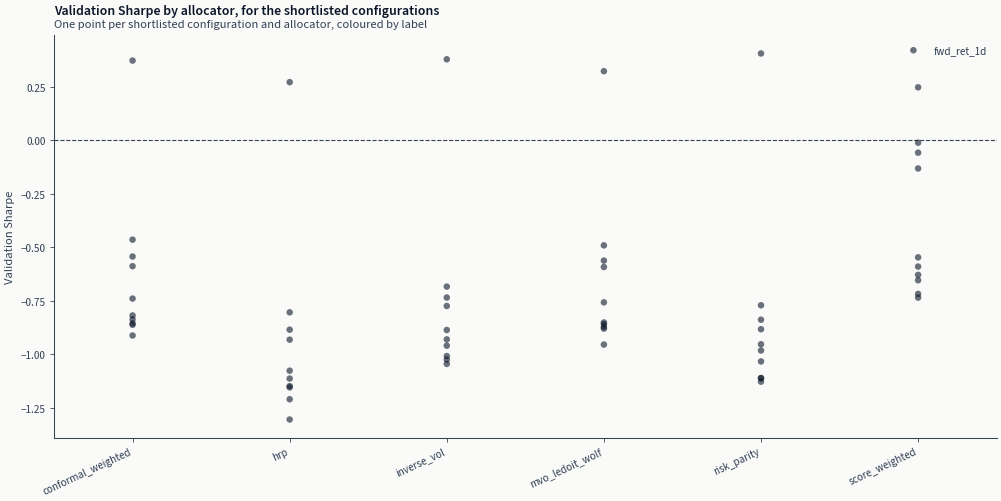

In [16]:
allocation_results = planned_population.select("label", "allocation", "backtest_hash").join(
    completed.select("backtest_hash", "sharpe"),
    on="backtest_hash",
    how="inner",
    validate="1:1",
)
if allocation_results.height != planned_population.height:
    raise RuntimeError("The plotted allocation population differs from the planned population")

fig, ax = plt.subplots(figsize=(10, 5))
allocator_order = allocation_results.get_column("allocation").unique().sort().to_list()
labels = allocation_results.get_column("label").unique().sort().to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(labels), categorical=True)
for index, label in enumerate(labels):
    label_rows = allocation_results.filter(pl.col("label") == label)
    positions = [allocator_order.index(name) for name in label_rows.get_column("allocation")]
    # A small fixed offset per label so three points on one allocator stay countable rather than
    # landing on top of each other; the horizontal position carries no meaning of its own.
    offset = (index - (len(labels) - 1) / 2) * 0.14
    ax.scatter(
        [position + offset for position in positions],
        label_rows["sharpe"],
        alpha=0.6,
        s=22,
        color=palette[index],
        edgecolors="none",
        label=label,
    )
zero_line(ax)
ax.set_xticks(range(len(allocator_order)), allocator_order, rotation=25, ha="right")
ax.set_xlim(-0.5, len(allocator_order) - 0.5)
ax.set_ylabel("Validation Sharpe")
add_message_title(
    ax,
    "Validation Sharpe by allocator, for the shortlisted configurations",
    subtitle="One point per shortlisted configuration and allocator, coloured by label",
)
ax.legend(fontsize=8, frameon=False)
# The alt text counts rather than asserts: how many allocators clear zero anywhere is a fact about
# the frame, and a panel described as beating the baseline when it does not is a claim the data
# refutes.
_above = allocation_results.group_by("allocation").agg(best=pl.col("sharpe").max())
_n_positive = int((_above.get_column("best") > 0).sum())
show_with_alt(
    fig,
    "A scatter plot with one column per allocator and a dashed line at zero. Each point is one "
    "shortlisted configuration re-sized by that allocator, placed at its validation Sharpe, with "
    "the three labels offset slightly from one another and coloured separately. Counted from the "
    f"underlying frame, {_n_positive} of {_above.height} allocators reach a positive Sharpe on at "
    "least one configuration.",
)

## What to notice

**Every row here differs from its baseline in exactly one thing.** Same model, same checkpoint,
same names on the same dates, different money. That is what makes a difference attributable to
the sizing rule.

**Equal weight is hard to beat on a broad cross-section, and the reason is estimation.** The
allocators that read a covariance matrix have to estimate one from a finite window, and a
three-thousand-name cross-section gives far fewer observations per parameter than a small
universe does. An allocator that does not beat equal weight here has not shown that sizing is
irrelevant; it has shown that the estimate it needed was not accurate enough to pay for itself.

**The shortlist bounds what this can find.** Allocators are compared only on strategies equal
weight already ranked highly, so nothing here can discover one whose value is rescuing a model
equal weight buried.

**Still gross of costs, and the allocators differ in turnover.** A rule that reweights more
aggressively trades more, so an ordering established here can change once
[`19_costs`](19_costs.ipynb) charges for it.

**Known limitations.** The covariance-reading allocators are sensitive to their lookback, and one
window per allocator is declared rather than swept, so nothing here separates an allocator's
method from its window. Validation folds have been read many times over by this point.

**Next**: [`18_risk_management`](18_risk_management.ipynb) lays rules on top that can close a
position before the next rebalance.